### Imports

In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np

### Load Data

In [2]:
variables = xr.open_dataset("../data_cache/loadedData/uk_aligned.nc")
blines = gpd.read_file("../data_cache/loadedData/uk_blines_exploded.gpkg")

FLOWERING_SEASON = {
    1: 0.0,   # Jan
    2: 0.1,   # Feb
    3: 0.4,   # Mar
    4: 0.7,   # Apr
    5: 1.0,   # May
    6: 1.0,   # Jun
    7: 1.0,   # Jul
    8: 0.8,   # Aug
    9: 0.5,   # Sep
    10: 0.2,  # Oct
    11: 0.0,  # Nov
    12: 0.0,  # Dec
}

LANDCOVER_SUITABILITY = {
    10: 0.7,  # Tree cover
    20: 0.9,  # Shrubland
    30: 1.0,  # Grassland
    40: 0.6,  # Cropland
    50: 0.0,  # Built-up
    60: 0.1,  # Bare/sparse vegetation
    80: 0.0,  # Water
    90: 0.7,  # Herbaceous wetland
}

variables

<xarray.Dataset> Size: 47kB
Dimensions:      (lat: 47, lon: 41)
Coordinates:
  * lat          (lat) float64 376B 61.0 60.75 60.5 60.25 ... 50.0 49.75 49.5
  * lon          (lon) float64 328B -8.0 -7.75 -7.5 -7.25 ... 1.25 1.5 1.75 2.0
Data variables:
    temperature  (lat, lon) float32 8kB ...
    spei         (lat, lon) float32 8kB ...
    ndvi         (lat, lon) float64 15kB ...
    landcover    (lat, lon) float64 15kB ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1927
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

### Scoring Functions

In [3]:
def heat_score(temp_c, temp_opt: float=20, sigma: float=6) -> float:
    return np.exp(-((temp_c - temp_opt)**2) / (2 * sigma**2))
    
def drought_score(spei: float) -> float:
    return np.clip((spei + 2) / 2, 0, 1)

def landcover_score(code: int) -> float:
    return LANDCOVER_SUITABILITY.get(code, 0.0)

def flowering_score(month: int) -> float:
    return FLOWERING_SEASON[month]

def ndvi_score(ndvi: float) -> float:
    return np.clip(ndvi, 0, 1)

def habitat_quality(ndvi: float,landcover: float,flowering: float) -> float:
    return (0.5 * ndvi_score(ndvi) + 0.3 * landcover + 0.2 * flowering)



def suitability(heat: float, drought: float, habitat: float) -> float:
    return np.minimum(heat, drought) * habitat #Liebegs Law of the minimum

In [ ]:
heat_suit = xr.apply_ufunc(
    heat_score,
    variables["temperature"],
    vectorize=True
)

drought_suit = xr.apply_ufunc(
    drought_score,
    variables["spei"],
    vectorize=True
)

landcover_suit = xr.apply_ufunc(
    landcover_score,
    variables["landcover"],
    vectorize=True
)

month = 7
flowering_suit = flowering_score(month)

flowering_grid = xr.full_like(
    variables["temperature"],
    flowering_suit
)

habitat_suit = xr.apply_ufunc(
    habitat_quality,
    variables["ndvi"],
    landcover_suit,
    flowering_grid,
    vectorize=True
)

final_suitability = xr.apply_ufunc(
    suitability,
    heat_suit,
    drought_suit,
    habitat_suit,
    vectorize=True
)

pollinator_ds = xr.Dataset(
    {
        "heat_suitability": heat_suit,
        "drought_suitability": drought_suit,
        "habitat_quality": habitat_suit,
        "pollinator_suitability": final_suitability,
    }
)

<xarray.Dataset> Size: 47kB
Dimensions:                 (lat: 47, lon: 41)
Coordinates:
  * lat                     (lat) float64 376B 61.0 60.75 60.5 ... 49.75 49.5
  * lon                     (lon) float64 328B -8.0 -7.75 -7.5 ... 1.5 1.75 2.0
Data variables:
    heat_suitability        (lat, lon) float32 8kB 0.244 0.2345 ... 0.9881
    drought_suitability     (lat, lon) float32 8kB 0.0 0.0 0.0 ... 1.0 1.0 1.0
    habitat_quality         (lat, lon) float64 15kB nan 0.2 0.2 ... nan nan nan
    pollinator_suitability  (lat, lon) float64 15kB nan 0.0 0.0 ... nan nan nan

In [5]:
print(pollinator_ds.pollinator_suitability.min())
print(pollinator_ds.pollinator_suitability.max())

<xarray.DataArray 'pollinator_suitability' ()> Size: 8B
array(0.)
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1927
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
<xarray.DataArray 'pollinator_suitability' ()> Size: 8B
array(0.93095487)
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1927


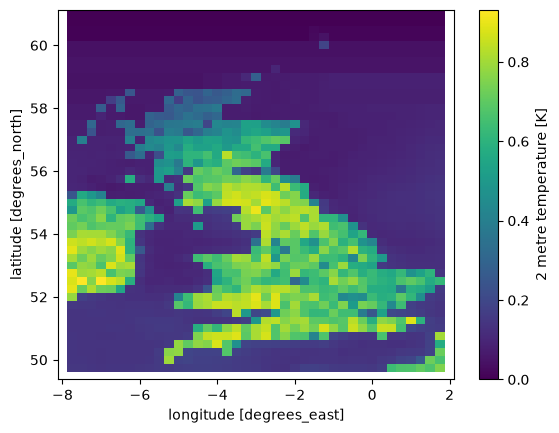

In [6]:
pollinator_ds.pollinator_suitability.plot()

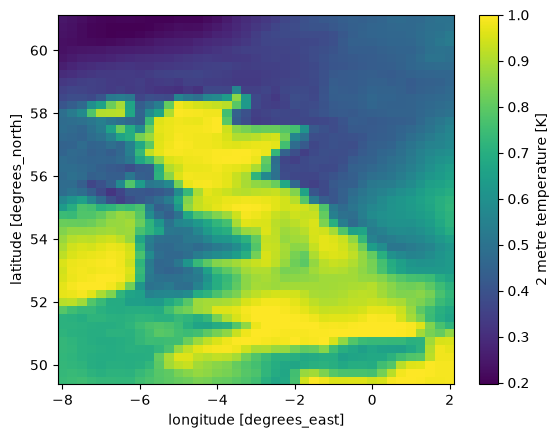

In [7]:
pollinator_ds["heat_suitability"].plot()

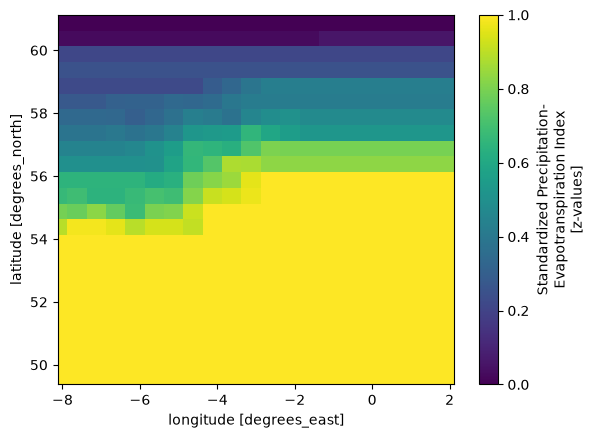

In [8]:
pollinator_ds["drought_suitability"].plot()

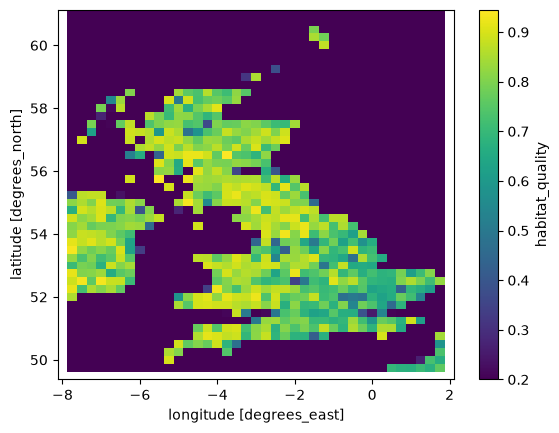

In [9]:
pollinator_ds["habitat_quality"].plot()

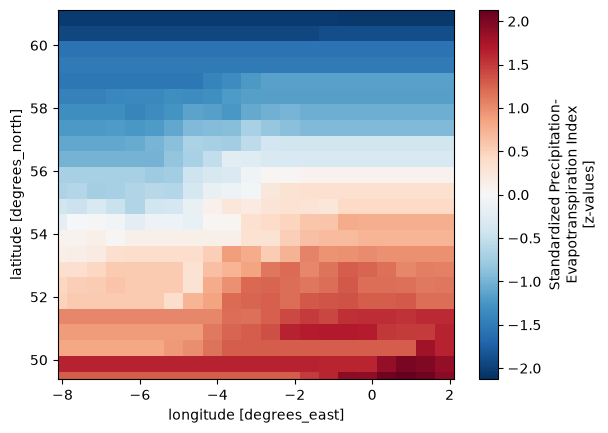

In [12]:
variables["spei"].plot()

### Final Suitability + Blines

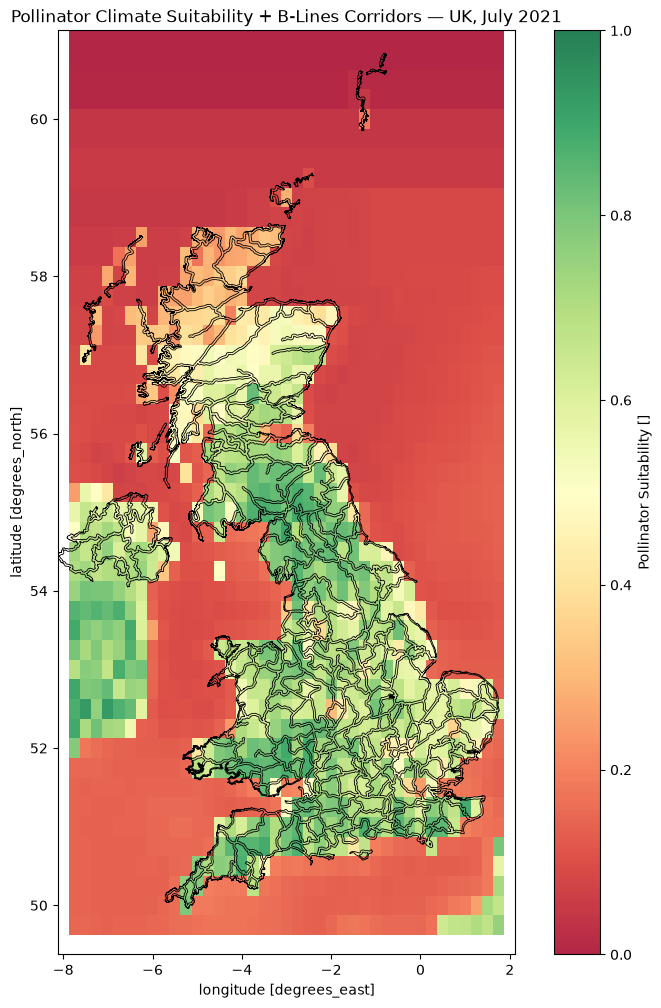

In [14]:
import matplotlib.pyplot as plt

pollinator_ds["pollinator_suitability"].attrs["long_name"] = "Pollinator Suitability"
pollinator_ds["pollinator_suitability"].attrs["units"] = ""

fig, ax = plt.subplots(figsize=(10, 12))

pollinator_ds["pollinator_suitability"].plot(
    ax=ax, cmap="RdYlGn", vmin=0, vmax=1, alpha=0.85
)

blines.plot(ax=ax, color="none", edgecolor="black", linewidth=0.6)

plt.title("Pollinator Climate Suitability + B-Lines Corridors — UK, July 2021")
plt.show()